In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     GlobalAveragePooling2D, Dense)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import cv2   # for Grad-CAM heatmap overlay


In [3]:
# Paths
project_path   = Path("../..").resolve()
processed_path = project_path / "data" / "processed"
xai_path       = project_path / "XAI_2026"
models_path    = xai_path / "models"
artifacts_path = xai_path / "artifacts"
outputs_path   = xai_path / "outputs"

# Create directories
models_path.mkdir(parents=True, exist_ok=True)
artifacts_path.mkdir(parents=True, exist_ok=True)
outputs_path.mkdir(parents=True, exist_ok=True)



In [5]:
processed_path

WindowsPath('C:/Users/shahe/4XAI/Project/data/processed')

In [4]:
project_path 

WindowsPath('C:/Users/shahe/4XAI/Project')

In [6]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.17.0
GPU available: False


##  2 — Load Data

In [7]:
# Load mel spectrograms
X = np.load(processed_path / "ravdess_mel_spectrograms.npy")
y = np.load(processed_path / "ravdess_emotion_labels_encoded.npy")
classes = np.load(processed_path / "ravdess_emotion_classes.npy",
                  allow_pickle=True)

print("Mel spectrograms shape:", X.shape)   
print("Labels shape:",           y.shape)  
print("Classes:",                classes)   


n_classes = len(classes)
print("Number of classes:", n_classes)      # 8

Mel spectrograms shape: (1440, 128, 282, 1)
Labels shape: (1440,)
Classes: ['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
Number of classes: 8


## 3 — Normalize & Split

In [18]:
# Normalize pixel values to [0, 1]
# Mel spectrograms are in dB range (-80 to 0)
# Normalize so CNN trains stably
X_norm = (X - X.min()) / (X.max() - X.min())

print("Value range after normalization:")
print(f"  Min: {X_norm.min():.3f}")    # 0.000
print(f"  Max: {X_norm.max():.3f}")    # 1.000

# Convert labels to one-hot encoding
# e.g. class 3 → [0, 0, 0, 1, 0, 0, 0, 0]
y_cat = to_categorical(y, num_classes=n_classes)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_cat,
    test_size=0.1,
    stratify=y,          # preserve class balance
    random_state=42
)

# Further split train into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print("\nData splits:")
print(f"  Train:      {X_train.shape}")   # (1036, 128, 282, 1)
print(f"  Validation: {X_val.shape}")     # (116, 128, 282, 1)
print(f"  Test:       {X_test.shape}")    # (288, 128, 282, 1)

Value range after normalization:
  Min: 0.000
  Max: 1.000

Data splits:
  Train:      (1036, 128, 282, 1)
  Validation: (260, 128, 282, 1)
  Test:       (144, 128, 282, 1)


## 4 — Build CNN Architecture

In [9]:
def build_cnn(input_shape=(128, 282, 1), n_classes=8):
    inputs = Input(shape=input_shape)

    # Block 1 — learn basic patterns
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2 — learn mid-level patterns
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 3 — learn high-level emotion patterns
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 4 — final conv layer (IMPORTANT for Grad-CAM)
    x = Conv2D(256, (3, 3), activation='relu', padding='same',
               name='last_conv')(x)    # ← named for Grad-CAM
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 282, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 282, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 282, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 141, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 141, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 141, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 141, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 70, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 70, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 70, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 70, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ last_conv (Conv2D)                   │ (None, 16, 35, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 35, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 35, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │              

 Total params: 423,688 (1.62 MB)

 Trainable params: 422,728 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 5 — Compile & Train

In [10]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,          # stop if no improvement for 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(models_path / "cnn_best_model.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Training complete ")

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.2293 - loss: 1.9690
Epoch 1: val_accuracy improved from None to 0.12069, saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_best_model.keras

Epoch 1: finished saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 940ms/step - accuracy: 0.2664 - loss: 1.9229 - val_accuracy: 0.1207 - val_loss: 3.2121
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.3349 - loss: 1.7464
Epoch 2: val_accuracy did not improve from 0.12069
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 879ms/step - accuracy: 0.3629 - loss: 1.7143 - val_accuracy: 0.1207 - val_loss: 6.2739
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.3860 - loss: 1.6304
Epoch 3: val_accuracy improved from 0.12069 to 0.12931, saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_best_model.keras

Epoch 3: finished saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_b

## 6 — Plot Training History

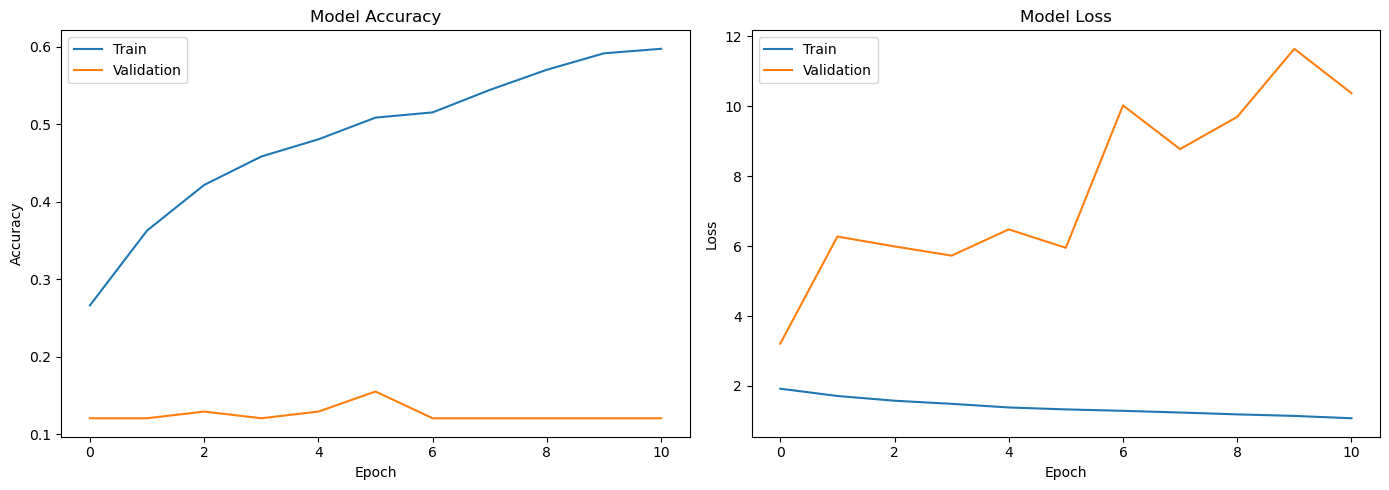

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(outputs_path / "cnn_training_history.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
def build_cnn_v2(input_shape=(128, 282, 1), n_classes=8):
    inputs = Input(shape=input_shape)

    # Block 1 — simpler, fewer filters
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 3 — last conv (for Grad-CAM)
    x = Conv2D(64, (3, 3), activation='relu', padding='same',
               name='last_conv')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.4)(x)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [20]:
X_norm = np.zeros_like(X)
for i in range(len(X)):
    sample = X[i]
    X_norm[i] = (sample - sample.min()) / (sample.max() - sample.min() + 1e-8)

print("Per-sample normalization done ")
print("Shape:", X_norm.shape)   # (1440, 128, 282, 1)

Per-sample normalization done 
Shape: (1440, 128, 282, 1)


In [21]:
from tensorflow.keras.layers import RandomFlip, RandomZoom, GaussianNoise

def build_cnn_v2(input_shape=(128, 282, 1), n_classes=8):
    inputs = Input(shape=input_shape)

    # Data augmentation layers (only active during training)
    x = GaussianNoise(0.05)(inputs)      # add slight noise
    x = RandomZoom(0.1)(x)               # slight zoom variation

    # Block 1
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 3 — named for Grad-CAM
    x = Conv2D(64, (3, 3), activation='relu', padding='same',
               name='last_conv')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.4)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [23]:
cnn_model_v2 = build_cnn_v2()

cnn_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # slower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',    # ← watch accuracy not loss
        patience=20,               # stop if no improvement for 15 epochs
        restore_best_weights=True,
        mode='max',                # accuracy should MAXIMIZE
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(models_path / "cnn_best_model_v2.keras"),
        monitor='val_accuracy',    # ← save best accuracy model
        save_best_only=True,
        mode='max',
        verbose=1
    )
]
history = cnn_model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,                    # more epochs, early stopping handles it
    batch_size=16,                 # smaller batch = better generalization
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1106 - loss: 2.3471
Epoch 1: val_accuracy improved from None to 0.13077, saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_best_model_v2.keras

Epoch 1: finished saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\cnn_best_model_v2.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.1207 - loss: 2.2359 - val_accuracy: 0.1308 - val_loss: 2.1079
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1319 - loss: 2.1331
Epoch 2: val_accuracy did not improve from 0.13077
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.1525 - loss: 2.1065 - val_accuracy: 0.1308 - val_loss: 2.1281
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.1757 - loss: 2.0592
Epoch 3: val_accuracy did not improve from 0.13077
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.1815 - loss: 2.0393 - val_accuracy: 0.1308 - val_loss: 2.1222
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 129

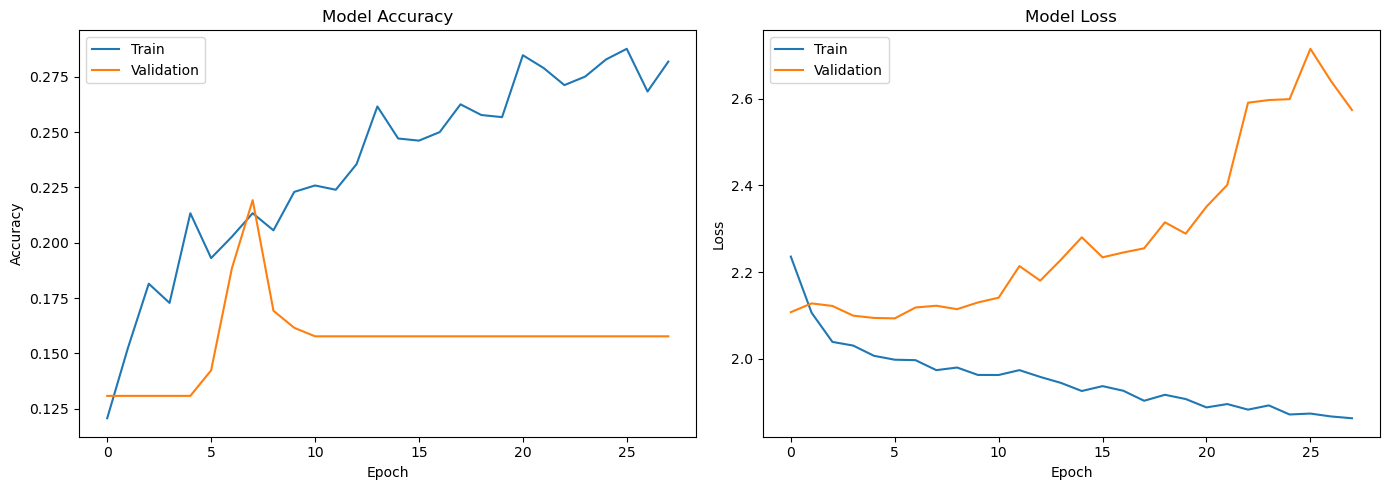

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(outputs_path / "cnn_training_history.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Check current value range
print("Current range:")
print(f"  Min: {X.min():.2f}")
print(f"  Max: {X.max():.2f}")

# Mel spectrograms after power_to_db are typically -80 to 0
# Normalize to 0-1 per sample
X_norm = np.zeros_like(X, dtype=np.float32)
for i in range(len(X)):
    sample = X[i, :, :, 0]
    min_val = sample.min()
    max_val = sample.max()
    X_norm[i, :, :, 0] = (sample - min_val) / (max_val - min_val + 1e-8)

print("\nAfter normalization:")
print(f"  Min: {X_norm.min():.3f}")   # should be 0.0
print(f"  Max: {X_norm.max():.3f}")   # should be 1.0

Current range:
  Min: -80.00
  Max: 0.00

After normalization:
  Min: 0.000
  Max: 1.000


In [27]:
import tensorflow as tf

def spec_augment(spectrogram, num_freq_masks=2, num_time_masks=2,
                 freq_mask_size=15, time_mask_size=30):
    augmented = spectrogram.copy()
    freq_bins, time_steps = augmented.shape[0], augmented.shape[1]

    # Frequency masking — mask horizontal strips
    for _ in range(num_freq_masks):
        f = np.random.randint(0, freq_mask_size)
        f0 = np.random.randint(0, freq_bins - f)
        augmented[f0:f0+f, :, :] = 0    # erase frequency band

    # Time masking — mask vertical strips
    for _ in range(num_time_masks):
        t = np.random.randint(0, time_mask_size)
        t0 = np.random.randint(0, time_steps - t)
        augmented[:, t0:t0+t, :] = 0    # erase time segment

    return augmented

# Apply to training data only
X_train_aug = np.array([
    spec_augment(X_train[i]) for i in range(len(X_train))
])

print("Augmented training shape:", X_train_aug.shape)
# Same shape — just with random masks applied

Augmented training shape: (1036, 128, 282, 1)


In [28]:
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization,
                                      MaxPooling2D, Dropout, Reshape,
                                      GRU, Dense, GlobalAveragePooling1D)

def build_crnn(input_shape=(128, 282, 1), n_classes=8):
    inputs = Input(shape=input_shape)

    # CNN part — extract frequency features
    x = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)        # (64, 141, 16)
    x = Dropout(0.3)(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)        # (32, 70, 32)
    x = Dropout(0.3)(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same',
               name='last_conv')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)        # (16, 35, 64)
    x = Dropout(0.3)(x)

    # Bridge — collapse frequency dimension
    # Reshape: (16, 35, 64) → (35, 16×64) = (35, 1024)
    shape = x.shape
    x = Reshape((shape[2], shape[1] * shape[3]))(x)
    # Now shape = (time_steps, features)

    # RNN part — read temporal sequence
    x = GRU(64, return_sequences=True)(x)   # reads left to right
    x = GRU(32)(x)                          # final temporal summary
    x = Dropout(0.4)(x)

    # Classification
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    return Model(inputs, outputs)

crnn_model = build_crnn()
crnn_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 128, 282, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 128, 282, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128, 282, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 64, 141, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64, 141, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 64, 141, 32)         │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 64, 141, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 32, 70, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 32, 70, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ last_conv (Conv2D)                   │ (None, 32, 70, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 32, 70, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 16, 35, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 16, 35, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 35, 1024)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 35, 64)              │         209,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             5

 Total params: 245,064 (957.28 KB)

 Trainable params: 244,840 (956.41 KB)

 Non-trainable params: 224 (896.00 B)

In [29]:
crnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(models_path / "crnn_best_model.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history_crnn = crnn_model.fit(
    X_train_aug,    # use augmented training data
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.1168 - loss: 2.1520
Epoch 1: val_accuracy improved from None to 0.06538, saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\crnn_best_model.keras

Epoch 1: finished saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\crnn_best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 338ms/step - accuracy: 0.1149 - loss: 2.1418 - val_accuracy: 0.0654 - val_loss: 2.0963
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.1327 - loss: 2.0975
Epoch 2: val_accuracy improved from 0.06538 to 0.15769, saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\crnn_best_model.keras

Epoch 2: finished saving model to C:\Users\shahe\4XAI\Project\XAI_2026\models\crnn_best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.1322 - loss: 2.1073 - val_accuracy: 0.1577 - val_loss: 2.1123
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.1474 - loss: 2.0864
Epoch 3: val_accuracy did no

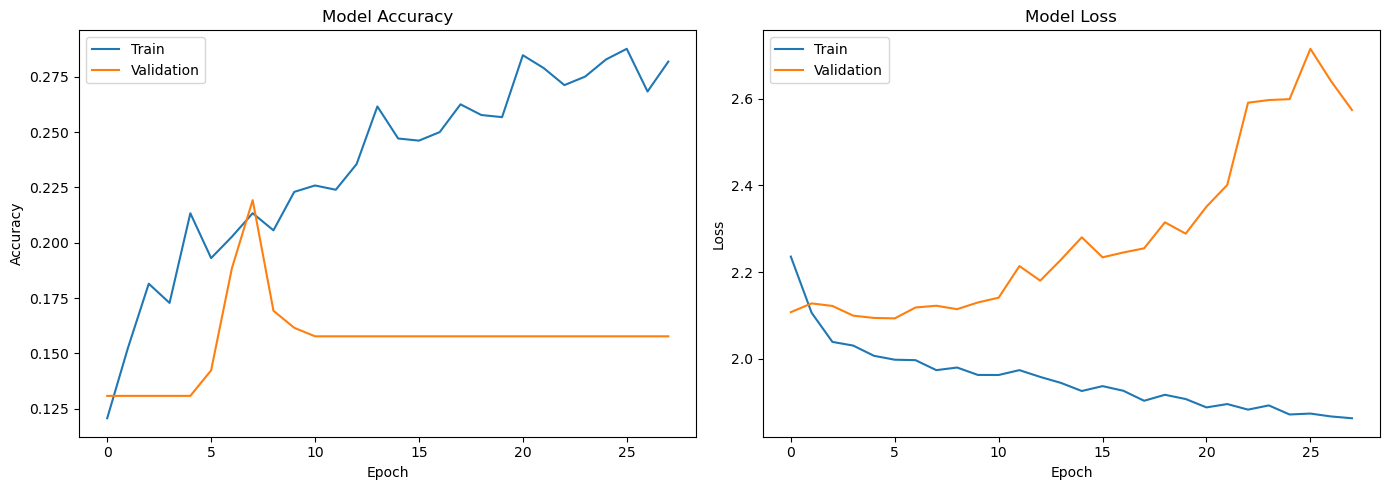

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(outputs_path / "cnn_training_history.png",
            dpi=150, bbox_inches='tight')
plt.show()